In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/all_departures_stacked.csv"

df = pd.read_csv(file_path, low_memory=False)

print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

df.head()

Rows: 1065169
Columns: 17


,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),Wheels-off time,Taxi-Out time (Minutes),Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes)
0,AS,01/01/2016,15.0,N552AS,SEA,18:45,19:10,400.0,373.0,25.0,19:26,16.0,0.0,0.0,0.0,0.0,0.0
1,AS,01/01/2016,25.0,N492AS,SEA,07:00,07:03,405.0,371.0,3.0,07:25,22.0,0.0,0.0,0.0,0.0,0.0
2,AS,01/01/2016,33.0,N549AS,PDX,17:10,17:20,399.0,332.0,10.0,17:32,12.0,0.0,0.0,0.0,0.0,0.0
3,AS,01/01/2016,769.0,N526AS,SAN,18:15,18:12,419.0,370.0,-3.0,18:31,19.0,0.0,0.0,0.0,0.0,0.0
4,AS,01/01/2017,15.0,N568AS,SEA,18:50,21:40,400.0,384.0,170.0,22:08,28.0,36.0,0.0,0.0,0.0,118.0


In [ ]:
df["Date"] = pd.to_datetime(
    df["Date (MM/DD/YYYY)"],
    format="%m/%d/%Y",
    errors="coerce"
)

df["Month"] = df["Date"].dt.month
df["Day_of_Week"] = df["Date"].dt.dayofweek  # 0=Monday, 6=Sunday
df["Year"] = df["Date"].dt.year

df[["Date (MM/DD/YYYY)", "Date", "Month", "Day_of_Week", "Year"]].head()

,Date (MM/DD/YYYY),Date,Month,Day_of_Week,Year
0,01/01/2016,2016-01-01,1.0,4.0,2016.0
1,01/01/2016,2016-01-01,1.0,4.0,2016.0
2,01/01/2016,2016-01-01,1.0,4.0,2016.0
3,01/01/2016,2016-01-01,1.0,4.0,2016.0
4,01/01/2017,2017-01-01,1.0,6.0,2017.0


In [ ]:
import numpy as np

df["Season"] = np.select(
    [
        df["Month"].isin([12, 1, 2]),
        df["Month"].isin([3, 4, 5]),
        df["Month"].isin([6, 7, 8]),
        df["Month"].isin([9, 10, 11]),
    ],
    ["Winter", "Spring", "Summer", "Fall"],
    default="Unknown"   # <-- string default fixes dtype issue
)

In [ ]:

df["Season"].value_counts(dropna=False)
df[["Date", "Month", "Season"]].head()

,Date,Month,Season
0,2016-01-01,1.0,Winter
1,2016-01-01,1.0,Winter
2,2016-01-01,1.0,Winter
3,2016-01-01,1.0,Winter
4,2017-01-01,1.0,Winter


In [ ]:
print("Shape of dataset:", df.shape)
print("\nColumn Names:")
print(df.columns.tolist())

print("\nData Types:")
print(df.dtypes)

Shape of dataset: (1065169, 22)

Column Names:
['Carrier Code', 'Date (MM/DD/YYYY)', 'Flight Number', 'Tail Number', 'Destination Airport', 'Scheduled departure time', 'Actual departure time', 'Scheduled elapsed time (Minutes)', 'Actual elapsed time (Minutes)', 'Departure delay (Minutes)', 'Wheels-off time', 'Taxi-Out time (Minutes)', 'Delay Carrier (Minutes)', 'Delay Weather (Minutes)', 'Delay National Aviation System (Minutes)', 'Delay Security (Minutes)', 'Delay Late Aircraft Arrival (Minutes)', 'Date', 'Month', 'Day_of_Week', 'Year', 'Season']

Data Types:
Carrier Code                                        object
Date (MM/DD/YYYY)                                   object
Flight Number                                      float64
Tail Number                                         object
Destination Airport                                 object
Scheduled departure time                            object
Actual departure time                               object
Scheduled elapsed ti

In [ ]:
# Count missing values in each column
missing_summary = df.isna().sum()
# df.isna() creates a True/False mask of missing values
# .sum() counts how many True values (i.e., missing entries) per column

# Calculate percentage of missing values
missing_percent = df.isna().mean() * 100
# .mean() works because True=1, False=0
# So mean gives proportion of missing values
# Multiply by 100 to convert to percentage

# Combine both into one DataFrame for easier viewing
missing_df = pd.DataFrame({
    "Missing Count": missing_summary,
    "Missing %": missing_percent
})

# Sort columns by highest missing percentage
missing_df.sort_values(by="Missing %", ascending=False).head(15)

,Missing Count,Missing %
Tail Number,4183,0.392708
Date (MM/DD/YYYY),8,0.000751
Destination Airport,8,0.000751
Flight Number,8,0.000751
Scheduled departure time,8,0.000751
Actual departure time,8,0.000751
Delay National Aviation System (Minutes),8,0.000751
Scheduled elapsed time (Minutes),8,0.000751
Actual elapsed time (Minutes),8,0.000751
Departure delay (Minutes),8,0.000751


In [ ]:
# Count fully duplicated rows
print("Total duplicate rows:", df.duplicated().sum())
# df.duplicated() returns True for rows that are exact duplicates
# .sum() counts them

Total duplicate rows: 7


In [ ]:
duplicate_rows_full = df[df.duplicated(keep=False)]

duplicate_rows_full.sort_values(by=["Carrier Code", "Flight Number", "Date"]).head(20)

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,Delay Carrier (Minutes),Delay Weather (Minutes),Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes),Date,Month,Day_of_Week,Year,Season
21583,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
224056,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
408655,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
413958,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
828715,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
909117,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
952514,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown
1065168,SOURCE: Bureau of Transportation Statistics,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaT,NaN,NaN,NaN,Unknown


In [ ]:
df = df[df["Departure delay (Minutes)"].notna()]

df.duplicated().sum()

np.int64(0)

In [ ]:
import numpy as np

df["Delay_Category"] = np.select(
    [
        df["Departure delay (Minutes)"] < 0,
        (df["Departure delay (Minutes)"] >= 0) &
        (df["Departure delay (Minutes)"] <= 5),
        (df["Departure delay (Minutes)"] > 5) &
        (df["Departure delay (Minutes)"] <= 20),
        df["Departure delay (Minutes)"] > 20
    ],
    [
        "Early Departure",
        "On Time (0-5 min)",
        "Minor Delay (6-20 min)",
        "Late (20+ min)"
    ],
    default="Unknown"
)

category_counts = df["Delay_Category"].value_counts()
category_percent = df["Delay_Category"].value_counts(normalize=True) * 100

delay_summary = pd.DataFrame({
    "Count": category_counts,
    "Percentage": category_percent
})

delay_summary



,Count,Percentage
Delay_Category,,
Early Departure,614700,57.709586
Late (20+ min),180853,16.978936
On Time (0-5 min),155709,14.618353
Minor Delay (6-20 min),113899,10.693125


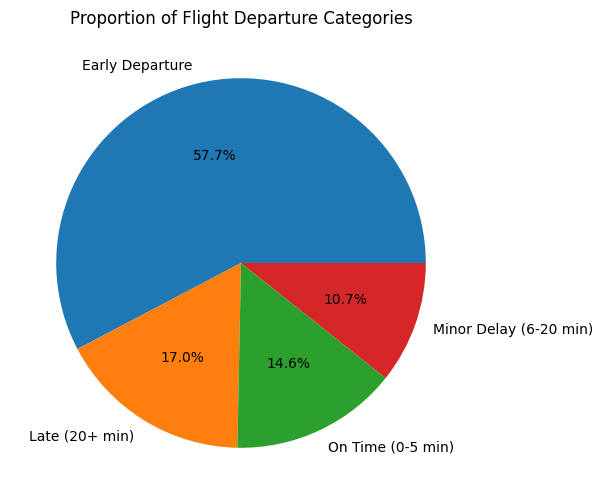

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))

df["Delay_Category"] \
    .value_counts() \
    .drop("Unknown", errors="ignore") \
    .plot(kind="pie", autopct="%1.1f%%")

plt.ylabel("")
plt.title("Proportion of Flight Departure Categories")
plt.show()

In [ ]:
late_flights = df[df["Departure delay (Minutes)"] > 20]

print("Number of late flights:", late_flights.shape[0])
print("Percent of total flights:",
      round(late_flights.shape[0] / df.shape[0] * 100, 2), "%")

Number of late flights: 180853
Percent of total flights: 16.98 %


In [ ]:
late_flights["Departure delay (Minutes)"].describe()

,Departure delay (Minutes)
count,180853.000000
mean,81.778306
std,87.475892
min,21.000000
25%,33.000000
50%,54.000000
75%,98.000000
max,2810.000000


In [ ]:
late_flights["Departure delay (Minutes)"].quantile([0.90, 0.95, 0.99, 0.999])

,Departure delay (Minutes)
0.900,166.000
0.950,226.000
0.990,403.000
0.999,985.148


In [ ]:
# Recreate late cohort
late_flights = df[df["Departure delay (Minutes)"] > 20]

# Recreate zoomed subset
late_zoom = late_flights[
    late_flights["Departure delay (Minutes)"] <= 500]

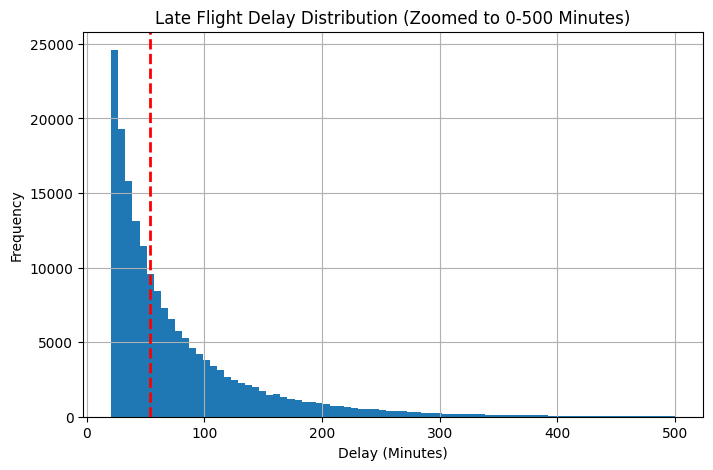

In [ ]:
plt.figure(figsize=(8,5))

late_zoom["Departure delay (Minutes)"].hist(bins=80)

plt.axvline(late_flights["Departure delay (Minutes)"].median(),
            color='red', linestyle='dashed', linewidth=2)

plt.title("Late Flight Delay Distribution (Zoomed to 0-500 Minutes)")
plt.xlabel("Delay (Minutes)")
plt.ylabel("Frequency")
plt.show()

In [ ]:
df["Carrier Name"] = df["Carrier Code"].map(carrier_mapping)

df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,Delay National Aviation System (Minutes),Delay Security (Minutes),Delay Late Aircraft Arrival (Minutes),Date,Month,Day_of_Week,Year,Season,Delay_Category,Carrier Name
0,AS,01/01/2016,15.0,N552AS,SEA,18:45,19:10,400.0,373.0,25.0,...,0.0,0.0,0.0,2016-01-01,1.0,4.0,2016.0,Winter,Late (20+ min),Alaska Airlines
1,AS,01/01/2016,25.0,N492AS,SEA,07:00,07:03,405.0,371.0,3.0,...,0.0,0.0,0.0,2016-01-01,1.0,4.0,2016.0,Winter,On Time (0-5 min),Alaska Airlines
2,AS,01/01/2016,33.0,N549AS,PDX,17:10,17:20,399.0,332.0,10.0,...,0.0,0.0,0.0,2016-01-01,1.0,4.0,2016.0,Winter,Minor Delay (6-20 min),Alaska Airlines
3,AS,01/01/2016,769.0,N526AS,SAN,18:15,18:12,419.0,370.0,-3.0,...,0.0,0.0,0.0,2016-01-01,1.0,4.0,2016.0,Winter,Early Departure,Alaska Airlines
4,AS,01/01/2017,15.0,N568AS,SEA,18:50,21:40,400.0,384.0,170.0,...,0.0,0.0,118.0,2017-01-01,1.0,6.0,2017.0,Winter,Late (20+ min),Alaska Airlines


In [ ]:
carrier_mapping = {
    "AA": "American Airlines",
    "DL": "Delta Air Lines",
    "UA": "United Airlines",
    "WN": "Southwest Airlines",
    "AS": "Alaska Airlines",
    "B6": "JetBlue Airways",
    "NK": "Spirit Airlines",
    "F9": "Frontier Airlines",
}

df[df["Carrier Name"].isna()]["Carrier Code"].unique()



array([], dtype=object)

In [ ]:
carrier_summary = df.groupby("Carrier Name").agg(
    total_flights=("Departure delay (Minutes)", "count"),
    late_flights=("Departure delay (Minutes)", lambda x: (x > 20).sum())
)

# Calculate late rate percentage
carrier_summary["late_rate_%"] = (
    carrier_summary["late_flights"] / carrier_summary["total_flights"] * 100
)

carrier_summary.sort_values("late_rate_%", ascending=False)


,total_flights,late_flights,late_rate_%
Carrier Name,,,
Frontier Airlines,5302,1222,23.047906
Spirit Airlines,43396,9945,22.916859
JetBlue Airways,414756,82355,19.856253
Southwest Airlines,80401,13019,16.192585
Delta Air Lines,184598,28177,15.263979
Alaska Airlines,21583,3197,14.812584
United Airlines,112653,15998,14.201131
American Airlines,202472,26940,13.305543


In [ ]:
late_only = df[df["Departure delay (Minutes)"] > 20]

carrier_late_severity = late_only.groupby("Carrier Name").agg(
    median_late_delay=("Departure delay (Minutes)", "median"),
    mean_late_delay=("Departure delay (Minutes)", "mean"),
    late_count=("Departure delay (Minutes)", "count")
)

carrier_late_severity.sort_values("median_late_delay", ascending=False)


,median_late_delay,mean_late_delay,late_count
Carrier Name,,,
United Airlines,57.0,87.531566,15998
Spirit Airlines,56.0,83.563901,9945
American Airlines,55.0,89.190831,26940
JetBlue Airways,55.0,78.623605,82355
Delta Air Lines,54.0,87.695177,28177
Frontier Airlines,50.0,87.031915,1222
Southwest Airlines,47.0,68.356633,13019
Alaska Airlines,46.0,66.736315,3197


In [ ]:
carrier_analysis = carrier_summary.merge(
    carrier_late_severity,
    left_index=True,
    right_index=True,
    how="left"
)

carrier_analysis.sort_values("late_rate_%", ascending=False)


,total_flights,late_flights,late_rate_%,median_late_delay,mean_late_delay,late_count
Carrier Name,,,,,,
Frontier Airlines,5302,1222,23.047906,50.0,87.031915,1222
Spirit Airlines,43396,9945,22.916859,56.0,83.563901,9945
JetBlue Airways,414756,82355,19.856253,55.0,78.623605,82355
Southwest Airlines,80401,13019,16.192585,47.0,68.356633,13019
Delta Air Lines,184598,28177,15.263979,54.0,87.695177,28177
Alaska Airlines,21583,3197,14.812584,46.0,66.736315,3197
United Airlines,112653,15998,14.201131,57.0,87.531566,15998
American Airlines,202472,26940,13.305543,55.0,89.190831,26940


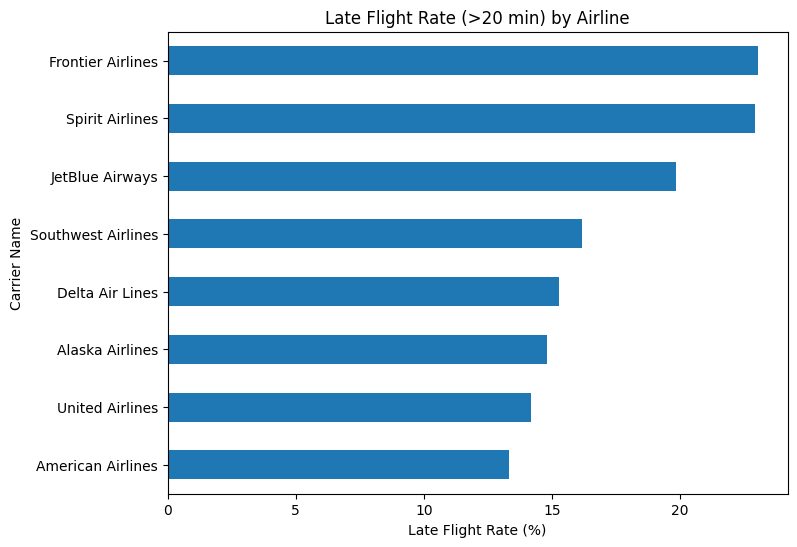

In [ ]:
import matplotlib.pyplot as plt

carrier_analysis.sort_values("late_rate_%")["late_rate_%"] \
    .plot(kind="barh", figsize=(8,6))

plt.xlabel("Late Flight Rate (%)")
plt.title("Late Flight Rate (>20 min) by Airline")
plt.show()

In [ ]:
season_summary = df.groupby("Season").agg(
    total_flights=("Departure delay (Minutes)", "count"),
    late_flights=("Departure delay (Minutes)", lambda x: (x > 20).sum())
)

season_summary["late_rate_%"] = (
    season_summary["late_flights"] / season_summary["total_flights"] * 100
)

season_summary.sort_values("late_rate_%", ascending=False)


,total_flights,late_flights,late_rate_%
Season,,,
Summer,283232,57852,20.425658
Spring,273228,44831,16.407908
Winter,243603,39680,16.288798
Fall,265098,38490,14.519159


In [ ]:
late_only = df[df["Departure delay (Minutes)"] > 20]

season_late_severity = late_only.groupby("Season").agg(
    median_late_delay=("Departure delay (Minutes)", "median"),
    mean_late_delay=("Departure delay (Minutes)", "mean"),
    late_count=("Departure delay (Minutes)", "count")
)

season_late_severity.sort_values("median_late_delay", ascending=False)


,median_late_delay,mean_late_delay,late_count
Season,,,
Summer,58.0,85.470511,57852
Winter,54.0,84.330544,39680
Spring,53.0,79.219915,44831
Fall,51.0,76.577501,38490


In [ ]:
season_analysis = season_summary.merge(
    season_late_severity,
    left_index=True,
    right_index=True,
    how="left"
)

season_analysis.sort_values("late_rate_%", ascending=False)


,total_flights,late_flights,late_rate_%,median_late_delay,mean_late_delay,late_count
Season,,,,,,
Summer,283232,57852,20.425658,58.0,85.470511,57852
Spring,273228,44831,16.407908,53.0,79.219915,44831
Winter,243603,39680,16.288798,54.0,84.330544,39680
Fall,265098,38490,14.519159,51.0,76.577501,38490


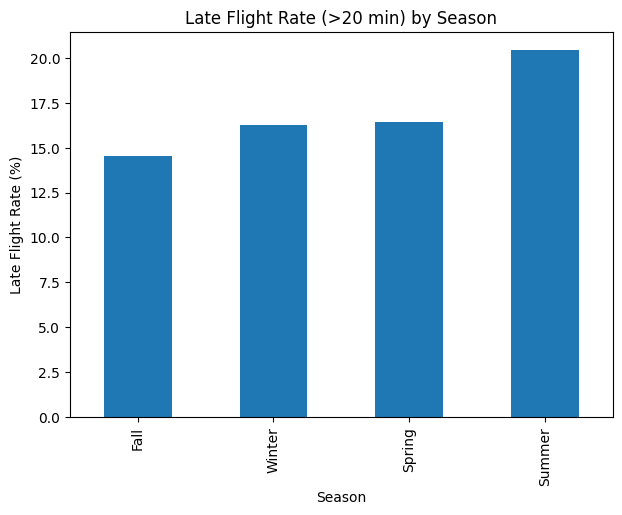

In [ ]:
import matplotlib.pyplot as plt

season_analysis.sort_values("late_rate_%")["late_rate_%"] \
    .plot(kind="bar", figsize=(7,5))

plt.ylabel("Late Flight Rate (%)")
plt.title("Late Flight Rate (>20 min) by Season")
plt.show()


In [ ]:
day_mapping = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday"
}

df["Day_Name"] = df["Day_of_Week"].map(day_mapping)


In [ ]:
dow_summary = df.groupby("Day_Name").agg(
    total_flights=("Departure delay (Minutes)", "count"),
    late_flights=("Departure delay (Minutes)", lambda x: (x > 20).sum())
)

dow_summary["late_rate_%"] = (
    dow_summary["late_flights"] / dow_summary["total_flights"] * 100
)

dow_summary.sort_values("late_rate_%", ascending=False)


,total_flights,late_flights,late_rate_%
Day_Name,,,
Monday,161127,29870,18.538172
Friday,161431,29747,18.427068
Thursday,160994,28616,17.774575
Sunday,150987,26752,17.718082
Saturday,124788,19465,15.598455
Tuesday,152437,23658,15.519854
Wednesday,153397,22745,14.827539


In [ ]:
late_only = df[df["Departure delay (Minutes)"] > 20]

dow_late_severity = late_only.groupby("Day_Name").agg(
    median_late_delay=("Departure delay (Minutes)", "median"),
    mean_late_delay=("Departure delay (Minutes)", "mean"),
    late_count=("Departure delay (Minutes)", "count")
)

dow_late_severity.sort_values("median_late_delay", ascending=False)


,median_late_delay,mean_late_delay,late_count
Day_Name,,,
Monday,56.0,84.640576,29870
Friday,55.0,81.521162,29747
Sunday,55.0,82.701705,26752
Tuesday,54.0,80.629935,23658
Thursday,54.0,80.606933,28616
Saturday,53.0,81.330747,19465
Wednesday,53.0,80.320862,22745


In [ ]:
dow_analysis = dow_summary.merge(
    dow_late_severity,
    left_index=True,
    right_index=True,
    how="left"
)

# Reorder days properly
ordered_days = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
dow_analysis = dow_analysis.loc[ordered_days]

dow_analysis


,total_flights,late_flights,late_rate_%,median_late_delay,mean_late_delay,late_count
Day_Name,,,,,,
Monday,161127,29870,18.538172,56.0,84.640576,29870
Tuesday,152437,23658,15.519854,54.0,80.629935,23658
Wednesday,153397,22745,14.827539,53.0,80.320862,22745
Thursday,160994,28616,17.774575,54.0,80.606933,28616
Friday,161431,29747,18.427068,55.0,81.521162,29747
Saturday,124788,19465,15.598455,53.0,81.330747,19465
Sunday,150987,26752,17.718082,55.0,82.701705,26752


In [ ]:
col = "Scheduled departure time"

# Parse HH:MM strings into datetime-like times (NaT if bad/missing)
t = pd.to_datetime(df[col], format="%H:%M", errors="coerce")

# Extract hour (0–23) and minute (0–59)
df["Scheduled_Hour"] = t.dt.hour
df["Scheduled_Minute"] = t.dt.minute

df[["Scheduled departure time", "Scheduled_Hour", "Scheduled_Minute"]].head()

df["Scheduled_Hour"].describe()



,Scheduled_Hour
count,1.065161e+06
mean,1.228466e+01
std,4.817336e+00
min,0.000000e+00
25%,8.000000e+00
50%,1.200000e+01
75%,1.700000e+01
max,2.300000e+01


In [ ]:
def time_bucket(hour):
    if pd.isna(hour):
        return "Unknown"
    hour = int(hour)
    if 5 <= hour <= 7:
        return "Early Morning"
    elif 8 <= hour <= 11:
        return "Morning Peak"
    elif 12 <= hour <= 14:
        return "Midday"
    elif 15 <= hour <= 17:
        return "Afternoon"
    elif 18 <= hour <= 21:
        return "Evening"
    else:
        return "Late Night"

df["Time_Bucket"] = df["Scheduled_Hour"].apply(time_bucket)

df["Time_Bucket"].value_counts(dropna=False)


,count
Time_Bucket,
Morning Peak,258958
Early Morning,247832
Afternoon,205616
Evening,190915
Midday,154367
Late Night,7473


In [ ]:
time_summary = df.groupby("Time_Bucket").agg(
    total_flights=("Departure delay (Minutes)", "count"),
    late_flights=("Departure delay (Minutes)", lambda x: (x > 20).sum())
)

time_summary["late_rate_%"] = (
    time_summary["late_flights"] / time_summary["total_flights"] * 100
)

time_summary


,total_flights,late_flights,late_rate_%
Time_Bucket,,,
Afternoon,205616,47694,23.195666
Early Morning,247832,17239,6.955922
Evening,190915,58107,30.436058
Late Night,7473,2205,29.506222
Midday,154367,25145,16.289103
Morning Peak,258958,30463,11.763684


In [ ]:
late_only = df[df["Departure delay (Minutes)"] > 20]

time_late_severity = late_only.groupby("Time_Bucket").agg(
    median_late_delay=("Departure delay (Minutes)", "median"),
    mean_late_delay=("Departure delay (Minutes)", "mean"),
    late_count=("Departure delay (Minutes)", "count")
)

time_late_severity


,median_late_delay,mean_late_delay,late_count
Time_Bucket,,,
Afternoon,54.0,80.258565,47694
Early Morning,50.0,85.303788,17239
Evening,60.0,83.590669,58107
Late Night,56.0,76.200000,2205
Midday,49.0,77.666653,25145
Morning Peak,51.0,82.503233,30463


In [ ]:
time_analysis = time_summary.merge(
    time_late_severity,
    left_index=True,
    right_index=True,
    how="left"
)

# Order buckets logically
ordered_buckets = [
    "Early Morning",
    "Morning Peak",
    "Midday",
    "Afternoon",
    "Evening",
    "Late Night"
]

time_analysis = time_analysis.loc[ordered_buckets]

time_analysis


,total_flights,late_flights,late_rate_%,median_late_delay,mean_late_delay,late_count
Time_Bucket,,,,,,
Early Morning,247832,17239,6.955922,50.0,85.303788,17239
Morning Peak,258958,30463,11.763684,51.0,82.503233,30463
Midday,154367,25145,16.289103,49.0,77.666653,25145
Afternoon,205616,47694,23.195666,54.0,80.258565,47694
Evening,190915,58107,30.436058,60.0,83.590669,58107
Late Night,7473,2205,29.506222,56.0,76.200000,2205


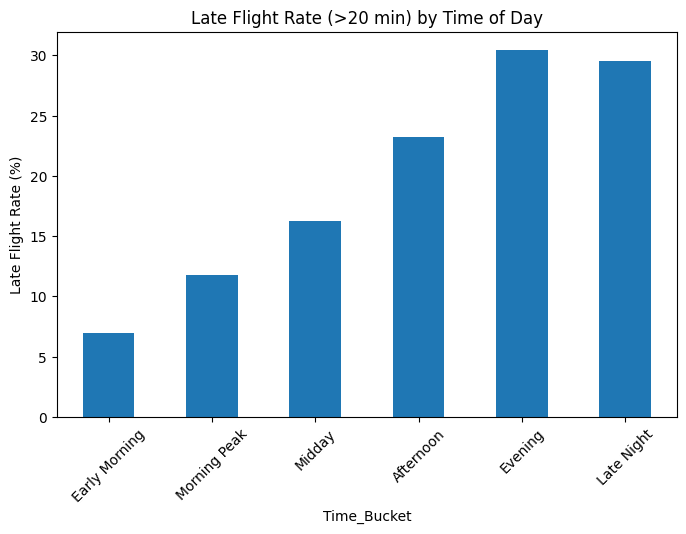

In [ ]:
import matplotlib.pyplot as plt

time_analysis["late_rate_%"].plot(
    kind="bar",
    figsize=(8,5)
)

plt.ylabel("Late Flight Rate (%)")
plt.title("Late Flight Rate (>20 min) by Time of Day")
plt.xticks(rotation=45)
plt.show()


In [ ]:
df["Delay_20"] = (df["Departure delay (Minutes)"] > 20).astype(int)

In [ ]:
def category_impact(df, category_col):
    summary = df.groupby(category_col).agg(
        total_flights=("Delay_20", "count"),
        late_rate=("Delay_20", "mean")
    )

    summary["late_rate_%"] = summary["late_rate"] * 100
    summary = summary.sort_values("late_rate_%", ascending=False)

    spread = summary["late_rate_%"].max() - summary["late_rate_%"].min()

    return summary, spread

In [ ]:
season_summary, season_spread = category_impact(df, "Season")
season_summary

,total_flights,late_rate,late_rate_%
Season,,,
Summer,283232,0.204257,20.425658
Spring,273228,0.164079,16.407908
Winter,243603,0.162888,16.288798
Fall,265098,0.145192,14.519159


In [ ]:
dow_summary, dow_spread = category_impact(df, "Day_Name")
dow_summary

,total_flights,late_rate,late_rate_%
Day_Name,,,
Monday,161127,0.185382,18.538172
Friday,161431,0.184271,18.427068
Thursday,160994,0.177746,17.774575
Sunday,150987,0.177181,17.718082
Saturday,124788,0.155985,15.598455
Tuesday,152437,0.155199,15.519854
Wednesday,153397,0.148275,14.827539


In [ ]:
time_summary, time_spread = category_impact(df, "Time_Bucket")
time_summary

,total_flights,late_rate,late_rate_%
Time_Bucket,,,
Evening,190915,0.304361,30.436058
Late Night,7473,0.295062,29.506222
Afternoon,205616,0.231957,23.195666
Midday,154367,0.162891,16.289103
Morning Peak,258958,0.117637,11.763684
Early Morning,247832,0.069559,6.955922


In [ ]:
carrier_summary, carrier_spread = category_impact(df, "Carrier Name")
carrier_summary

,total_flights,late_rate,late_rate_%
Carrier Name,,,
Frontier Airlines,5302,0.230479,23.047906
Spirit Airlines,43396,0.229169,22.916859
JetBlue Airways,414756,0.198563,19.856253
Southwest Airlines,80401,0.161926,16.192585
Delta Air Lines,184598,0.152640,15.263979
Alaska Airlines,21583,0.148126,14.812584
United Airlines,112653,0.142011,14.201131
American Airlines,202472,0.133055,13.305543


In [ ]:
# comparing rate spread across the categories is an effective way to gauge the impact of a specific variable. the larger the spread, the more impactful the variable is on the outcome (delays)

#0–3% → weak signal; 3–7% → moderate; 7–12% → strong; 12%+ → very strong


impact_comparison = {
    "Season": season_spread,
    "Day of Week": dow_spread,
    "Time of Day": time_spread,
    "Carrier": carrier_spread
}

impact_comparison

{'Season': 5.906499165188507,
 'Day of Week': 3.710632752605976,
 'Time of Day': 23.480136178094334,
 'Carrier': 9.742362967840466}

In [ ]:
def flight_length_bucket(minutes):
    if minutes < 90:
        return "Short Haul"
    elif minutes < 180:
        return "Medium Haul"
    elif minutes < 300:
        return "Long Haul"
    else:
        return "Very Long Haul"

df["Flight_Length_Category"] = df["Scheduled elapsed time (Minutes)"].apply(flight_length_bucket)

df["Flight_Length_Category"].value_counts()

,count
Flight_Length_Category,
Medium Haul,440789
Long Haul,347603
Very Long Haul,168421
Short Haul,108348


In [ ]:
#flight length does not appear to be a strong predictor of likelihood of delay

length_summary = df.groupby("Flight_Length_Category").agg(
    total_flights=("Delay_20", "count"),
    late_rate=("Delay_20", "mean")
)

length_summary["late_rate_%"] = length_summary["late_rate"] * 100
length_summary.sort_values("late_rate_%", ascending=False)

,total_flights,late_rate,late_rate_%
Flight_Length_Category,,,
Long Haul,347603,0.178252,17.825220
Very Long Haul,168421,0.168405,16.840537
Medium Haul,440789,0.165174,16.517427
Short Haul,108348,0.163566,16.356555


In [ ]:
late_only = df[df["Delay_20"] == 1]

length_severity = late_only.groupby("Flight_Length_Category").agg(
    median_late_delay=("Departure delay (Minutes)", "median"),
    mean_late_delay=("Departure delay (Minutes)", "mean"),
    late_count=("Departure delay (Minutes)", "count")
)

length_severity

,median_late_delay,mean_late_delay,late_count
Flight_Length_Category,,,
Long Haul,53.0,80.630171,61961
Medium Haul,55.0,82.085802,72807
Short Haul,59.0,87.450006,17722
Very Long Haul,52.0,79.953319,28363


In [ ]:
# These features are known BEFORE the flight departs (safe for prediction).
feature_cols = [
    "Carrier Name",                         # categorical: airline identity
    "Season",                               # categorical: seasonality patterns
    "Day_Name",                             # categorical: weekday patterns
    "Time_Bucket",                          # categorical: coarse time-of-day congestion
    "Scheduled_Hour",                       # numeric: hour of scheduled departure (0–23)
    "Scheduled elapsed time (Minutes)"      # numeric: planned flight duration
]

# X = model inputs (features)
X = df[feature_cols]

# y = model target
y = df["Delay_20"]

In [ ]:
# Most ML models require numeric inputs.
# One-hot encoding converts a category like "Winter" into columns like:
# Season_Spring, Season_SSummer, Season_Winter (one becomes 1, others 0).
#
# drop_first=True drops one dummy per category to reduce redundant columns.
X = pd.get_dummies(X, drop_first=True)

# Optional: check resulting feature count and a preview
print("Feature matrix shape:", X.shape)
X.head()

Feature matrix shape: (1065161, 23)


,Scheduled_Hour,Scheduled elapsed time (Minutes),Carrier Name_American Airlines,Carrier Name_Delta Air Lines,Carrier Name_Frontier Airlines,Carrier Name_JetBlue Airways,Carrier Name_Southwest Airlines,Carrier Name_Spirit Airlines,Carrier Name_United Airlines,Season_Spring,...,Day_Name_Saturday,Day_Name_Sunday,Day_Name_Thursday,Day_Name_Tuesday,Day_Name_Wednesday,Time_Bucket_Early Morning,Time_Bucket_Evening,Time_Bucket_Late Night,Time_Bucket_Midday,Time_Bucket_Morning Peak
0,18,400.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
1,7,405.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,True,False,False,False,False
2,17,399.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,18,419.0,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,True,False,False,False
4,18,400.0,False,False,False,False,False,False,False,False,...,False,True,False,False,False,False,True,False,False,False


In [ ]:
from sklearn.model_selection import train_test_split

# Train/test split:
# - model learns patterns from training data
# - model performance is evaluated on unseen test data (more honest estimate)
#
# stratify=y maintains the same % of delayed flights (class 1) in both train and test,
# which is important when classes are imbalanced.
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 20% held out for testing
    random_state=42,      # ensures reproducibility
    stratify=y            # preserves class distribution
)

print("Train size:", X_train.shape, "Test size:", X_test.shape)

Train size: (852128, 23) Test size: (213033, 23)


In [ ]:
from xgboost import XGBClassifier

# XGBoost is a gradient boosting algorithm that builds many small decision trees.
# Each new tree tries to correct the errors made by the previous trees.
#
# Key hyperparameters:
# - n_estimators: number of trees (more can improve performance but increase overfitting risk)
# - learning_rate: step size for boosting (smaller = slower learning, often better generalization)
# - max_depth: how complex each tree can be (higher = more complex patterns but more overfitting risk)
model = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.8,        # uses 80% of rows per tree -> reduces overfitting
    colsample_bytree=0.8, # uses 80% of columns per tree -> reduces overfitting
    random_state=42,
    eval_metric="logloss" # a standard classification loss metric
)

# Fit the model to the training data
model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

Time_Bucket_Evening                0.319227
Time_Bucket_Early Morning          0.296095
Scheduled_Hour                     0.102003
Time_Bucket_Morning Peak           0.064274
Season_Summer                      0.040996
Carrier Name_JetBlue Airways       0.026531
Carrier Name_Frontier Airlines     0.015732
Time_Bucket_Midday                 0.015596
Carrier Name_American Airlines     0.014791
Carrier Name_Spirit Airlines       0.014559
Day_Name_Wednesday                 0.013487
Carrier Name_Southwest Airlines    0.011492
Day_Name_Saturday                  0.009621
Day_Name_Tuesday                   0.009276
Season_Winter                      0.008829
dtype: float32


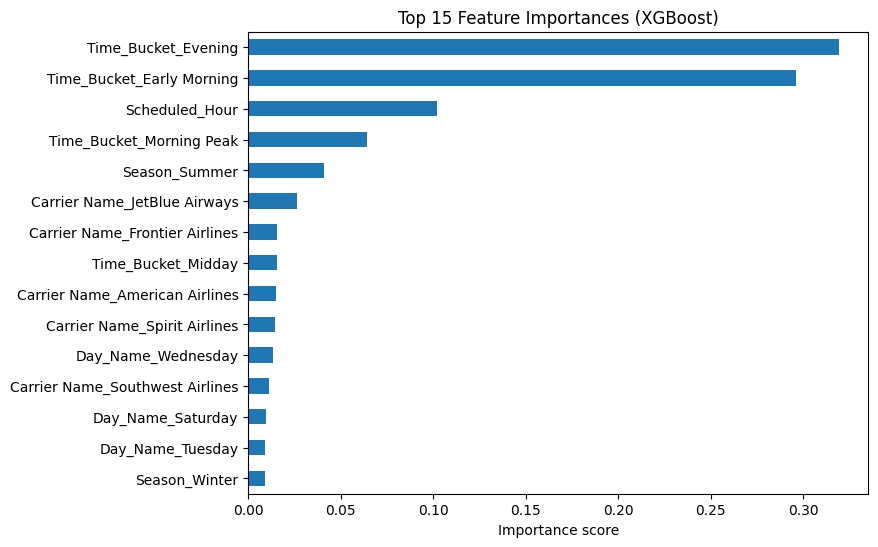

In [ ]:
# XGBoost gives an importance score per feature.
# With one-hot encoding, you'll see features like:
# Time_Bucket_Evening, Season_Winter, Carrier Name_Delta Air Lines, etc.
importances = pd.Series(model.feature_importances_, index=X.columns)

# Sort most important to least important
importances_sorted = importances.sort_values(ascending=False)

# Show top 15 most important features
print(importances_sorted.head(15))

# Plot top 15 for presentation
plt.figure(figsize=(8,6))
importances_sorted.head(15).sort_values().plot(kind="barh")
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance score")
plt.show()

In [ ]:
# Save the exact feature columns used during training (one-hot encoded)
MODEL_FEATURES = X.columns

def predict_delay20(
    carrier_name: str,
    season: str,
    day_name: str,
    time_bucket: str,
    scheduled_hour: int,
    scheduled_elapsed_min: int
):
    """
    Predict probability of Delay_20 (delay > 20 minutes) for a single hypothetical flight.
    Returns (probability, predicted_class).
    """

    # 1) Create a 1-row DataFrame in the SAME raw schema used before get_dummies
    sample = pd.DataFrame({
        "Carrier Name": [carrier_name],
        "Season": [season],
        "Day_Name": [day_name],
        "Time_Bucket": [time_bucket],
        "Scheduled_Hour": [scheduled_hour],
        "Scheduled elapsed time (Minutes)": [scheduled_elapsed_min]
    })

    # 2) One-hot encode this row
    sample_encoded = pd.get_dummies(sample, drop_first=True)

    # 3) Align columns with training features (missing dummies become 0)
    sample_encoded = sample_encoded.reindex(columns=MODEL_FEATURES, fill_value=0)

    # 4) Predict probability of class 1 (delay > 20) and class label
    proba = float(model.predict_proba(sample_encoded)[:, 1][0])
    pred = int(model.predict(sample_encoded)[0])

    return proba, pred

In [ ]:
proba, pred = predict_delay20(
    carrier_name="Frontier Airlines",
    season="Summer",
    day_name="Friday",
    time_bucket="Evening",
    scheduled_hour=19,
    scheduled_elapsed_min=150
)

print("P(delay > 20):", round(proba, 3))
print("Predicted class:", pred)

P(delay > 20): 0.263
Predicted class: 0


In [ ]:
# Testing extreme values led to prediction values of .07 to .222, suggesting we may have a thresholding issue

tests = [
    ("Frontier Airlines", "Winter", "Monday", "Early Morning", 6, 80),
    ("Frontier Airlines", "Summer", "Friday", "Late Night", 23, 300),
    ("Delta Air Lines", "Winter", "Monday", "Early Morning", 6, 80),
    ("Delta Air Lines", "Summer", "Friday", "Late Night", 23, 300),
]

for t in tests:
    proba, pred = predict_delay20(*t)
    print(t, "->", round(proba, 3), pred)

('Frontier Airlines', 'Winter', 'Monday', 'Early Morning', 6, 80) -> 0.07 0
('Frontier Airlines', 'Summer', 'Friday', 'Late Night', 23, 300) -> 0.222 0
('Delta Air Lines', 'Winter', 'Monday', 'Early Morning', 6, 80) -> 0.07 0
('Delta Air Lines', 'Summer', 'Friday', 'Late Night', 23, 300) -> 0.222 0


In [ ]:
#this code tests the impact of changing thresholds on the binary prediction
# precision measures trustworthiness of delay predictions. recall measures how many real delays that were detected

from sklearn.metrics import classification_report

y_proba = model.predict_proba(X_test)[:, 1]

for thr in [0.5, 0.4, 0.3, 0.25, 0.2, 0.15]:
    y_pred_thr = (y_proba >= thr).astype(int)
    print("\nThreshold:", thr)
    print(classification_report(y_test, y_pred_thr))


Threshold: 0.5
              precision    recall  f1-score   support

           0       0.83      1.00      0.91    176862
           1       0.42      0.00      0.00     36171

    accuracy                           0.83    213033
   macro avg       0.63      0.50      0.46    213033
weighted avg       0.76      0.83      0.75    213033


Threshold: 0.4
              precision    recall  f1-score   support

           0       0.84      0.98      0.90    176862
           1       0.42      0.06      0.10     36171

    accuracy                           0.83    213033
   macro avg       0.63      0.52      0.50    213033
weighted avg       0.77      0.83      0.77    213033


Threshold: 0.3
              precision    recall  f1-score   support

           0       0.86      0.91      0.88    176862
           1       0.36      0.25      0.30     36171

    accuracy                           0.80    213033
   macro avg       0.61      0.58      0.59    213033
weighted avg       0.77   

In [ ]:
#Because delay events are relatively rare, using the default 0.5 threshold resulted in very low recall.
#We therefore optimized the classification threshold based on F1 score to better balance precision and recall.
#F1 balances precision and recall

import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.5, 46)

best_threshold = 0
best_f1 = 0

for thr in thresholds:
    preds = (y_proba >= thr).astype(int)
    f1 = f1_score(y_test, preds)

    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

print("Best threshold:", best_threshold)
print("Best F1 score:", best_f1)

Best threshold: 0.19
Best F1 score: 0.3822522632100224


In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get predicted probabilities for class 1 (delay > 20)
y_proba = model.predict_proba(X_test)[:, 1]

# Compute False Positive Rate (FPR) and True Positive Rate (TPR)
fpr, tpr, thresholds = roc_curve(y_test, y_proba)

# Compute AUC score
roc_auc = roc_auc_score(y_test, y_proba)

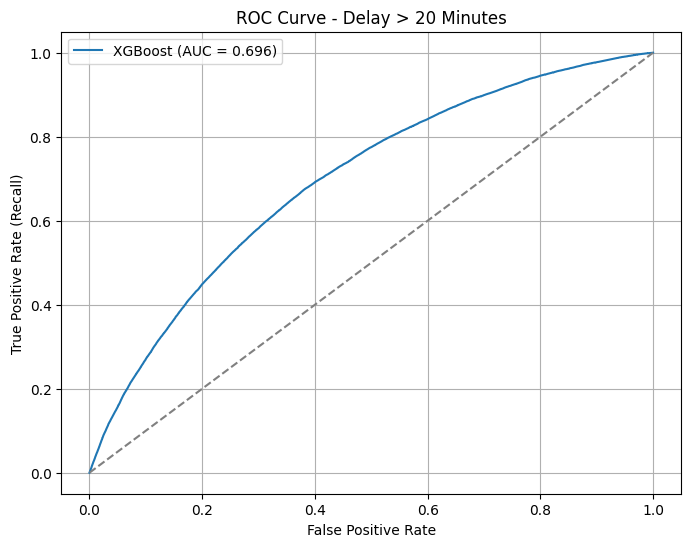

In [ ]:
#The gradient boosting model achieved an AUC of 0.696, indicating meaningful discrimination between delayed and non-delayed flights.
#While not perfect, this reflects the inherent unpredictability of operational disruptions when using only pre-departure features.

plt.figure(figsize=(8,6))

# Plot ROC curve
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")

# Plot diagonal random baseline
plt.plot([0, 1], [0, 1], linestyle="--", color="gray")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve - Delay > 20 Minutes")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#we will visualize what choosing the best threshold of .19 means with respect to the ROC curve

import numpy as np

best_threshold = 0.19

# Find threshold index closest to 0.19
idx = np.argmin(np.abs(thresholds - best_threshold))

fpr_best = fpr[idx]
tpr_best = tpr[idx]

print("Threshold:", thresholds[idx])
print("FPR at threshold:", fpr_best)
print("TPR at threshold:", tpr_best)

Threshold: 0.19000536
FPR at threshold: 0.32189503680835907
TPR at threshold: 0.6081944098863731


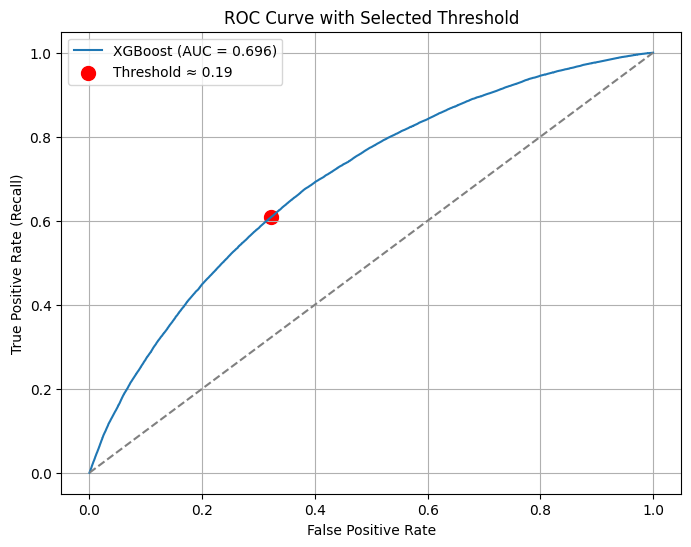

In [ ]:
plt.figure(figsize=(8,6))

# Plot full ROC curve
plt.plot(fpr, tpr, label=f"XGBoost (AUC = {roc_auc:.3f})")

# Plot random baseline
plt.plot([0,1], [0,1], linestyle="--", color="gray")

# Mark chosen threshold point
plt.scatter(fpr_best, tpr_best, color="red", s=100,
            label=f"Threshold ≈ {best_threshold}")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve with Selected Threshold")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
#re-running model to formally select the appropriate threshold
#split off validation set from training data

from sklearn.model_selection import train_test_split

X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

# retrain model on X_tr / y_tr
model.fit(X_tr, y_tr)

# probabilities on validation set
val_proba = model.predict_proba(X_val)[:, 1]

In [ ]:
#running F1 search on validation set

from sklearn.metrics import f1_score

thresholds = np.linspace(0.05, 0.5, 46)

best_threshold = 0
best_f1 = 0

for thr in thresholds:
    preds = (val_proba >= thr).astype(int)
    f1 = f1_score(y_val, preds)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thr

print("Best threshold (validation):", best_threshold)
print("Best F1 (validation):", best_f1)

Best threshold (validation): 0.19
Best F1 (validation): 0.3886558947516716


In [ ]:
#formally implement threshold, and evaluate on test set
#“We selected the classification threshold by maximizing F1 score on a held-out validation set,
#then evaluated final performance on the independent test set using the fixed threshold.”

from sklearn.metrics import classification_report, confusion_matrix

test_proba = model.predict_proba(X_test)[:, 1]
test_preds = (test_proba >= best_threshold).astype(int)

print("Locked threshold:", best_threshold)
print(confusion_matrix(y_test, test_preds))
print(classification_report(y_test, test_preds))

Locked threshold: 0.19
[[120022  56840]
 [ 14154  22017]]
              precision    recall  f1-score   support

           0       0.89      0.68      0.77    176862
           1       0.28      0.61      0.38     36171

    accuracy                           0.67    213033
   macro avg       0.59      0.64      0.58    213033
weighted avg       0.79      0.67      0.71    213033



In [ ]:
df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,Year,Season,Delay_Category,Carrier Name,Day_Name,Scheduled_Hour,Scheduled_Minute,Time_Bucket,Delay_20,Flight_Length_Category
0,AS,01/01/2016,15.0,N552AS,SEA,18:45,19:10,400.0,373.0,25.0,...,2016.0,Winter,Late (20+ min),Alaska Airlines,Friday,18,45,Evening,1,Very Long Haul
1,AS,01/01/2016,25.0,N492AS,SEA,07:00,07:03,405.0,371.0,3.0,...,2016.0,Winter,On Time (0-5 min),Alaska Airlines,Friday,7,0,Early Morning,0,Very Long Haul
2,AS,01/01/2016,33.0,N549AS,PDX,17:10,17:20,399.0,332.0,10.0,...,2016.0,Winter,Minor Delay (6-20 min),Alaska Airlines,Friday,17,10,Afternoon,0,Very Long Haul
3,AS,01/01/2016,769.0,N526AS,SAN,18:15,18:12,419.0,370.0,-3.0,...,2016.0,Winter,Early Departure,Alaska Airlines,Friday,18,15,Evening,0,Very Long Haul
4,AS,01/01/2017,15.0,N568AS,SEA,18:50,21:40,400.0,384.0,170.0,...,2017.0,Winter,Late (20+ min),Alaska Airlines,Sunday,18,50,Evening,1,Very Long Haul


In [ ]:
df["flight_date"] = df["Date"].dt.date

df.head()

,Carrier Code,Date (MM/DD/YYYY),Flight Number,Tail Number,Destination Airport,Scheduled departure time,Actual departure time,Scheduled elapsed time (Minutes),Actual elapsed time (Minutes),Departure delay (Minutes),...,Season,Delay_Category,Carrier Name,Day_Name,Scheduled_Hour,Scheduled_Minute,Time_Bucket,Delay_20,Flight_Length_Category,flight_date
0,AS,01/01/2016,15.0,N552AS,SEA,18:45,19:10,400.0,373.0,25.0,...,Winter,Late (20+ min),Alaska Airlines,Friday,18,45,Evening,1,Very Long Haul,2016-01-01
1,AS,01/01/2016,25.0,N492AS,SEA,07:00,07:03,405.0,371.0,3.0,...,Winter,On Time (0-5 min),Alaska Airlines,Friday,7,0,Early Morning,0,Very Long Haul,2016-01-01
2,AS,01/01/2016,33.0,N549AS,PDX,17:10,17:20,399.0,332.0,10.0,...,Winter,Minor Delay (6-20 min),Alaska Airlines,Friday,17,10,Afternoon,0,Very Long Haul,2016-01-01
3,AS,01/01/2016,769.0,N526AS,SAN,18:15,18:12,419.0,370.0,-3.0,...,Winter,Early Departure,Alaska Airlines,Friday,18,15,Evening,0,Very Long Haul,2016-01-01
4,AS,01/01/2017,15.0,N568AS,SEA,18:50,21:40,400.0,384.0,170.0,...,Winter,Late (20+ min),Alaska Airlines,Sunday,18,50,Evening,1,Very Long Haul,2017-01-01


In [ ]:
weather_path = "/content/drive/MyDrive/hourly_weather.csv"

hourly_weather = pd.read_csv(weather_path)

hourly_weather.head()

,weather_date,weather_hour,rain_flag,thunderstorm_flag,freezing_rain_flag,snow_flag,fog_flag,rain_intensity,thunderstorm_intensity,freezing_rain_intensity,snow_intensity,fog_intensity
0,2016-01-04,15,0,0,0,1,0,NaN,NaN,NaN,light,NaN
1,2016-01-04,16,0,0,0,1,0,NaN,NaN,NaN,light,NaN
2,2016-01-04,17,0,0,0,1,0,NaN,NaN,NaN,light,NaN
3,2016-01-04,18,0,0,0,1,0,NaN,NaN,NaN,light,NaN
4,2016-01-04,19,0,0,0,1,0,NaN,NaN,NaN,light,NaN


In [ ]:
hourly_weather["weather_date"] = pd.to_datetime(hourly_weather["weather_date"]).dt.date

In [ ]:
df["flight_date"] = df["Date"].dt.date

In [ ]:
merged_df = df.merge(
    hourly_weather,
    left_on=["flight_date", "Scheduled_Hour"],
    right_on=["weather_date", "weather_hour"],
    how="left"
)

In [ ]:
merged_df[[
    "flight_date",
    "Scheduled_Hour",
    "weather_date",
    "weather_hour",
    "rain_flag",
    "snow_flag",
    "fog_flag"
]].head(10)

,flight_date,Scheduled_Hour,weather_date,weather_hour,rain_flag,snow_flag,fog_flag
0,2016-01-01,18,NaN,NaN,NaN,NaN,NaN
1,2016-01-01,7,NaN,NaN,NaN,NaN,NaN
2,2016-01-01,17,NaN,NaN,NaN,NaN,NaN
3,2016-01-01,18,NaN,NaN,NaN,NaN,NaN
4,2017-01-01,18,NaN,NaN,NaN,NaN,NaN
5,2017-01-01,7,2017-01-01,7.0,1.0,0.0,0.0
6,2017-01-01,16,NaN,NaN,NaN,NaN,NaN
7,2017-01-01,18,NaN,NaN,NaN,NaN,NaN
8,2018-01-01,18,NaN,NaN,NaN,NaN,NaN
9,2018-01-01,16,NaN,NaN,NaN,NaN,NaN


In [ ]:
hourly_weather[
    (hourly_weather["weather_date"] == pd.to_datetime("2016-01-01").date()) &
    (hourly_weather["weather_hour"] == 18)
]

,weather_date,weather_hour,rain_flag,thunderstorm_flag,freezing_rain_flag,snow_flag,fog_flag,rain_intensity,thunderstorm_intensity,freezing_rain_intensity,snow_intensity,fog_intensity


In [ ]:
output_path = "/content/drive/MyDrive/merged_flight_weather.csv"

merged_df.to_csv(output_path, index=False)

print("Saved to:", output_path)

Saved to: /content/drive/MyDrive/merged_flight_weather.csv
